In [57]:
from types import SimpleNamespace
 
from src.adata_processing import SingleAdataLoader
from src.stagm import STAGM

In [58]:
DATA_PATH = "Dataset/Xeniumranger_V1_hSkin_Melanoma_Add_on_FFPE_outs/"

In [59]:
loader = SingleAdataLoader(
    path=DATA_PATH,
    source="xenium",
    n_top_genes=100_000,
    n_neighbors=6, 
    image_emb=False,
    label=False,
    normalize=True,
)

In [60]:
adata = loader.run()
adata

Edge probabilities: 100%|██████████| 87499/87499 [00:00<00:00, 139627.26it/s]

adata load done


AnnData object with n_obs × n_vars = 87499 × 382
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatialdata_attrs', 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh', 'feat', 'edge_probabilities'
    layers: None (.X)

In [ ]:
config = SimpleNamespace(
    seed=39788,
    learning_rate=5e-04,
    num_hidden=64,
    num_proj_hidden=64,
    activation="prelu",
    num_layers=1,
    drop_feature_rate_1=0.1,
    drop_feature_rate_2=0.2,
    tau=65,
    num_epochs=200,
    weight_decay=1e-5,
    num_clusters=8,
    num_gene=adata.obsm["feat"].shape[1],
    dropout=0.1,
    shuffle_ind=0,
    d_state=16,
    d_conv=4,
    minibatch_size = 12288,
    order_by_degree=False,
    bidirectional=True,
    k=None,
)


args = SimpleNamespace(slide="xenium_sample", label=False)

In [62]:
model = STAGM(args, config, single=True, refine=True, checkpoint_path="xenium_model.pt")
model.adata = adata

In [63]:
model.train()

=== train (mini-batch, 87499 nodes) ===


  0%|          | [00:00<?, ?it/s]

100%|██████████| [03:12<00:00,  1.04it/s]


In [64]:
model.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     94,849
  Trainable parameters: 94,849
  Model weight size:    0.36 MB
  Peak GPU memory:      1529.29 MB
  Training time:        3m 12.9s  (192.9s total)
  Time per epoch:       964.4 ms

  Loss curve:            first=8.9525  last=8.9495  min=8.9495  max=8.9525

  Embedding shape:      (87499, 64)
  Embedding norm — mean=0.1804  std=0.0783  min=0.0265  max=0.4420

embedding generated, go clustering


In [65]:
model.cluster(args.label)

Searching resolution...
Cluster count 18 is too large, adjusting end downward...
Cluster count 11 is too large, adjusting end downward...
Cluster count 7 is too small, adjusting end upward...
resolution=0.1650, cluster number=12
resolution=0.1600, cluster number=11
resolution=0.1550, cluster number=11
resolution=0.1500, cluster number=12
resolution=0.1450, cluster number=10
resolution=0.1400, cluster number=10
resolution=0.1350, cluster number=10
resolution=0.1300, cluster number=10
resolution=0.1250, cluster number=9
resolution=0.1200, cluster number=10
resolution=0.1150, cluster number=10
resolution=0.1100, cluster number=9
resolution=0.1050, cluster number=8
resolution=0.1000, cluster number=8
resolution=0.0950, cluster number=9
resolution=0.0900, cluster number=8
resolution=0.0850, cluster number=7
resolution=0.0800, cluster number=7
resolution=0.0750, cluster number=8
resolution=0.0700, cluster number=7
resolution=0.0650, cluster number=6
Best resolution found: 0.1050
calculate SC

domain
2    15282
4    13642
0    12696
1    11031
6    10822
5    10597
7     8440
3     4989
Name: count, dtype: int64


/opt/conda/envs/stagm-env/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


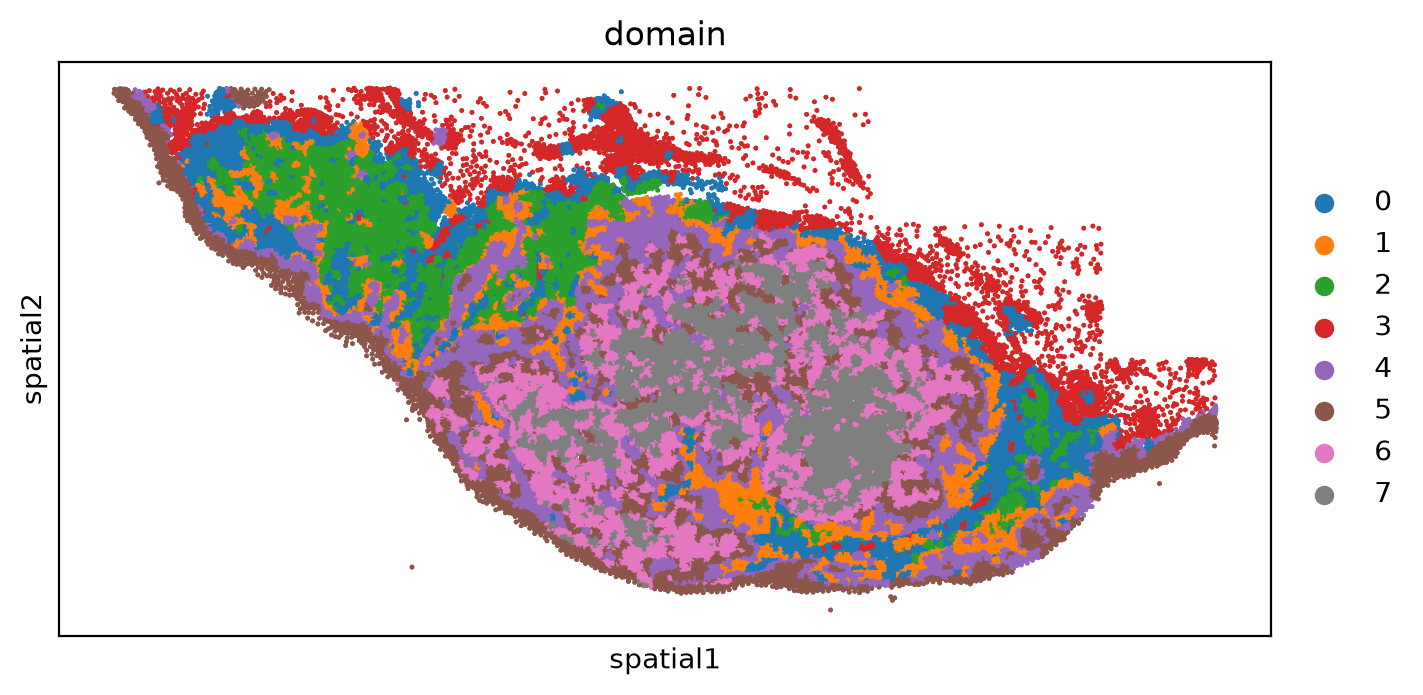

In [71]:
print(model.adata.obs["domain"].value_counts())
model.draw_xenium_spatial()

start umap


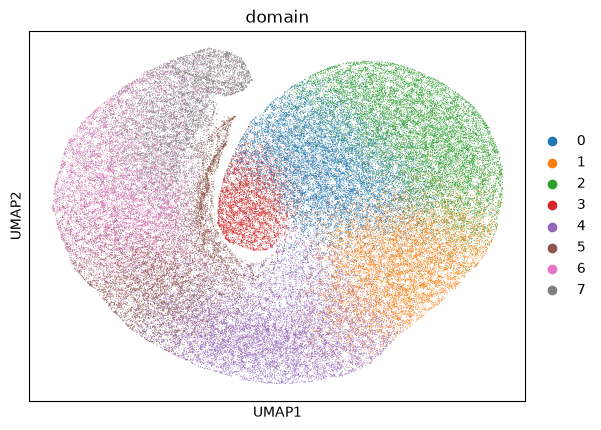

In [67]:
model.draw_umap()